In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix,
precision_score,
recall_score,
f1_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
RandomForestClassifier,
GradientBoostingClassifier
)

In [6]:
data = pd.read_csv("Crop_recommendation.csv")


In [7]:
data = data.drop_duplicates()

In [8]:
print(data.head())
print("Missing values:\n", data.isnull().sum())
print("Duplicate rows:", data.duplicated().sum())



    N   P   K  temperature   humidity    rainfall label
0  90  42  43    20.879744  82.002744  202.935536  rice
1  85  58  41    21.770462  80.319644  226.655537  rice
2  60  55  44    23.004459  82.320763  263.964248  rice
3  74  35  40    26.491096  80.158363  242.864034  rice
4  78  42  42    20.130175  81.604873  262.717340  rice
Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
rainfall       0
label          0
dtype: int64
Duplicate rows: 0


In [9]:
X = data.drop("label", axis=1)
y = data["label"]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

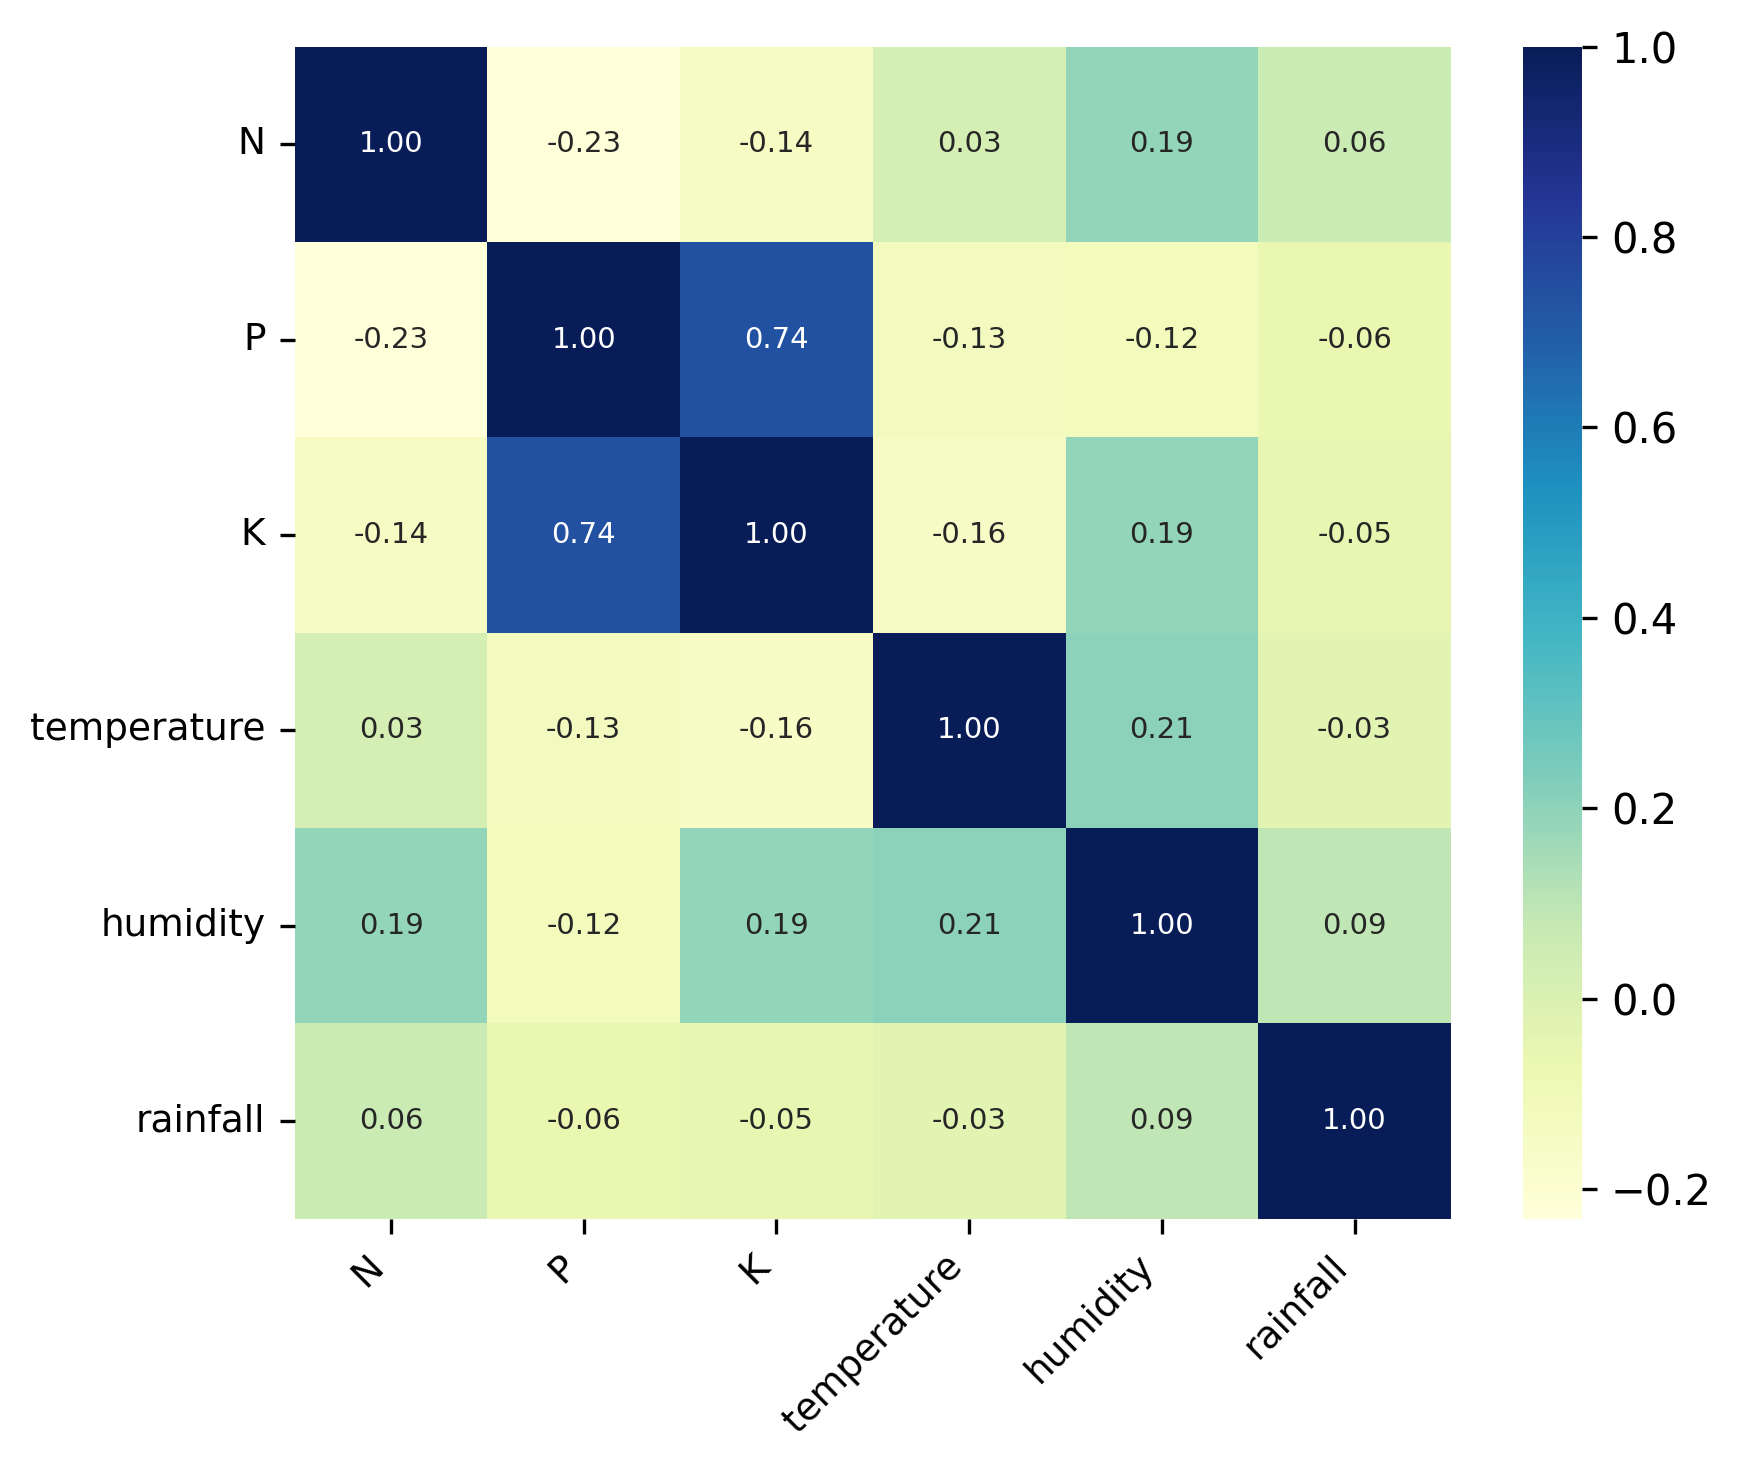

In [10]:
plt.figure(figsize=(6,5), dpi=300)
corr = X.corr()
sns.heatmap(
corr,
cmap="YlGnBu",
annot=True,
fmt=".2f",
annot_kws={"size":7},
cbar=True
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_matrix.pdf", format="pdf")
plt.savefig("correlation_matrix.png", dpi=600)
plt.show()

In [11]:
knn = KNeighborsClassifier()
svm = SVC()
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
models = {
"KNN": (knn, X_train_scaled, X_test_scaled),
"SVM": (svm, X_train_scaled, X_test_scaled),
"Random Forest": (rf, X_train, X_test),
"Gradient Boosting": (gb, X_train, X_test),
}

In [12]:
from sklearn.model_selection import cross_val_score

print("\nCROSS VALIDATION SCORES (5-FOLD)\n")

for name, (model, Xtr, _) in models.items():
    scores = cross_val_score(
        model,
        Xtr,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    print(
        f"{name:20s} : "
        f"Mean Accuracy = {scores.mean():.4f} | "
        f"Std Dev = {scores.std():.4f}"
    )


CROSS VALIDATION SCORES (5-FOLD)

KNN                  : Mean Accuracy = 0.9716 | Std Dev = 0.0062
SVM                  : Mean Accuracy = 0.9784 | Std Dev = 0.0029
Random Forest        : Mean Accuracy = 0.9938 | Std Dev = 0.0042
Gradient Boosting    : Mean Accuracy = 0.9881 | Std Dev = 0.0071


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

param_grids = {

    "KNN": {
        "n_neighbors": [3, 5, 7]
    },

    "SVM": {
        "kernel": ["linear", "rbf"],
        "C": [0.01, 0.1, 0.5, 1],
        "gamma": ["scale"]
    },

    "Random Forest": {
        "n_estimators": [10, 20, 30, 40, 50],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5, 10]
    },

    "Gradient Boosting": {
        "n_estimators": [10, 20, 50],
        "learning_rate": [0.05, 0.1]
    }
}

best_models = {}
results = []

print("\nGRIDSEARCH RESULTS\n")

for name, (model, Xtr, Xte) in models.items():

    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(Xtr, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    # Cross-validation accuracy
    cv_acc = grid.best_score_

    # Train accuracy
    train_pred = best_model.predict(Xtr)
    train_acc = accuracy_score(y_train, train_pred)

    # Test accuracy
    test_pred = best_model.predict(Xte)
    test_acc = accuracy_score(y_test, test_pred)

    # Store results
    results.append([
        name,
        grid.best_params_,
        round(cv_acc, 4),
        round(train_acc, 4),
        round(test_acc, 4)
    ])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "Best Parameters", "CV Accuracy", "Train Accuracy", "Test Accuracy"]
)

print("\nFINAL PERFORMANCE TABLE\n")
print(results_df)


GRIDSEARCH RESULTS


FINAL PERFORMANCE TABLE

               Model                                    Best Parameters  \
0                KNN                                 {'n_neighbors': 5}   
1                SVM     {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}   
2      Random Forest  {'max_depth': None, 'min_samples_split': 2, 'n...   
3  Gradient Boosting         {'learning_rate': 0.1, 'n_estimators': 50}   

   CV Accuracy  Train Accuracy  Test Accuracy  
0       0.9716          0.9835         0.9750  
1       0.9864          0.9875         0.9818  
2       0.9926          1.0000         0.9841  
3       0.9892          1.0000         0.9864  


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import time

param_grids = {

    "KNN": {
        "n_neighbors": [3,5,7]
    },

    "SVM": {
        "kernel":["linear","rbf"],
        "C":[0.01,0.1,0.5,1],
        "gamma":["scale"]
    },

    "Random Forest": {
        "n_estimators":[10,20,30,40,50],
        "max_depth":[None,5,10],
        "min_samples_split":[2,5,10]
    },

    "Gradient Boosting": {
        "n_estimators":[10,20,50],
        "learning_rate":[0.05,0.1]
    }
}

best_models = {}
results = []

print("\nGRID SEARCH RESULTS\n")

for name, (model, Xtr, Xte) in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    # -----------------------------
    # Training Time
    # -----------------------------
    start_train = time.time()

    grid.fit(Xtr, y_train)

    end_train = time.time()
    training_time = end_train - start_train

    best_model = grid.best_estimator_
    best_models[name] = best_model

    cv_acc = grid.best_score_

    # -----------------------------
    # Train Accuracy
    # -----------------------------
    train_pred = best_model.predict(Xtr)
    train_acc = accuracy_score(y_train, train_pred)

    # -----------------------------
    # Testing Time
    # -----------------------------
    start_test = time.time()

    test_pred = best_model.predict(Xte)

    end_test = time.time()
    testing_time = end_test - start_test

    # -----------------------------
    # Test Metrics
    # -----------------------------
    test_acc = accuracy_score(y_test, test_pred)

    precision = precision_score(
        y_test,
        test_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        test_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        test_pred,
        average='weighted'
    )

    results.append([
        name,
        grid.best_params_,
        round(cv_acc,4),
        round(train_acc,4),
        round(test_acc,4),
        round(precision,4),
        round(recall,4),
        round(f1,4),
        round(training_time,4),
        round(testing_time,6)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Best Parameters",
        "CV Accuracy",
        "Train Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Training Time (s)",
        "Testing Time (s)"
    ]
)

print("\nFINAL PERFORMANCE TABLE\n")

print(results_df)
from tabulate import tabulate

print(tabulate(results_df, headers='keys', tablefmt='grid', showindex=False))


GRID SEARCH RESULTS


FINAL PERFORMANCE TABLE

               Model                                    Best Parameters  \
0                KNN                                 {'n_neighbors': 5}   
1                SVM     {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}   
2      Random Forest  {'max_depth': None, 'min_samples_split': 2, 'n...   
3  Gradient Boosting         {'learning_rate': 0.1, 'n_estimators': 50}   

   CV Accuracy  Train Accuracy  Test Accuracy  Precision  Recall  F1-Score  \
0       0.9716          0.9835         0.9750     0.9756  0.9750    0.9749   
1       0.9864          0.9875         0.9818     0.9832  0.9818    0.9818   
2       0.9926          1.0000         0.9841     0.9861  0.9841    0.9841   
3       0.9892          1.0000         0.9864     0.9875  0.9864    0.9863   

   Training Time (s)  Testing Time (s)  
0             0.1155          0.004646  
1             2.6134          0.012793  
2            24.8642          0.008358  
3            76.3862 

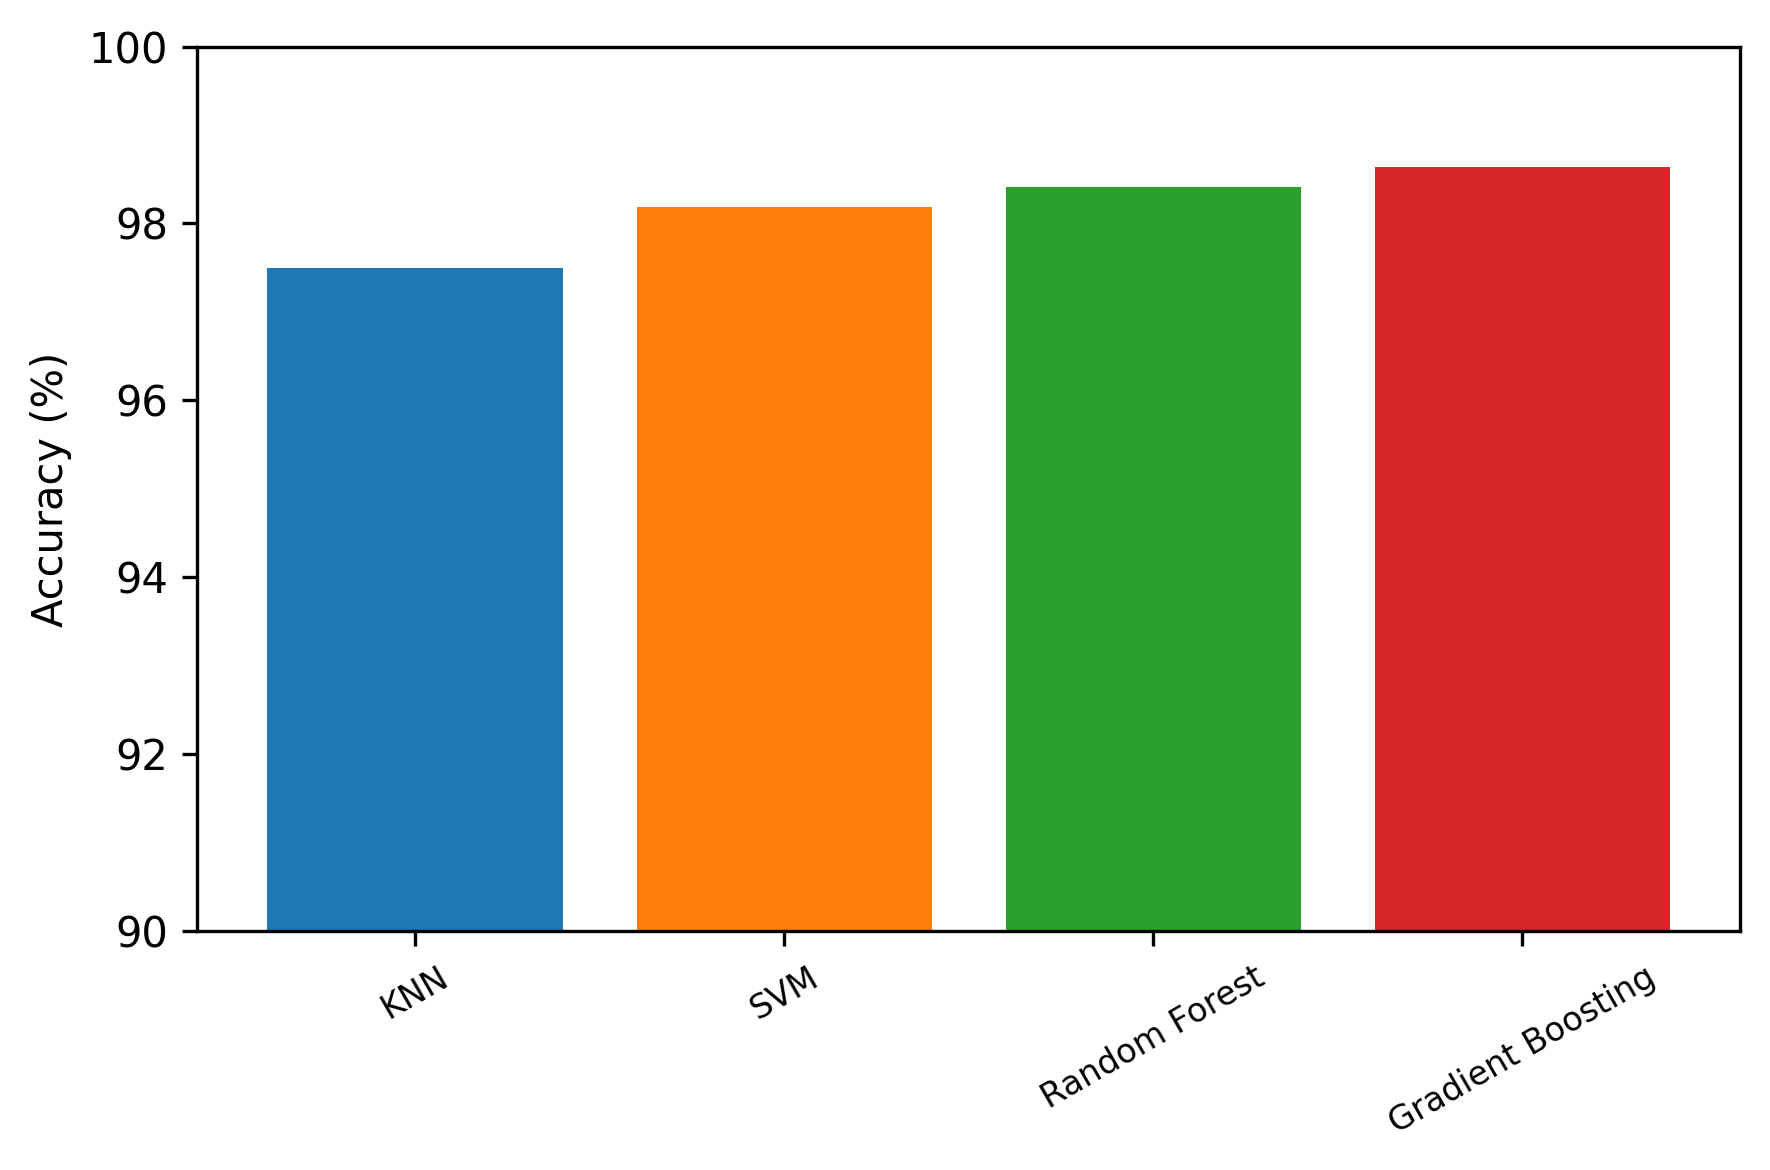

In [15]:
# =========================================
# IEEE STYLE PERFORMANCE – ACCURACY ONLY
# =========================================

model_names = []
accuracy_values = []

for name, model in best_models.items():

    if name in ["KNN", "SVM"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    model_names.append(name)
    accuracy_values.append(accuracy_score(y_test, y_pred) * 100)  # convert to %

# Create DataFrame
accuracy_df = pd.DataFrame({
    "Model": model_names,
    "Test Accuracy (%)": accuracy_values
})

accuracy_df.to_csv("model_accuracy_comparison.csv", index=False)

# ======================
# Plot Accuracy Comparison (Different Colors)
# ======================

plt.figure(figsize=(6,4), dpi=300)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Test Accuracy (%)"],
    color=colors[:len(accuracy_df)]
)

plt.ylabel("Accuracy (%)", fontsize=10)
plt.ylim(90, 100)
plt.xticks(rotation=30, fontsize=8)

plt.tight_layout()

plt.savefig("model_accuracy_comparison.pdf", format="pdf")
plt.savefig("model_accuracy_comparison.png", dpi=600)

plt.show()

/tmp/ipykernel_519/311888576.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


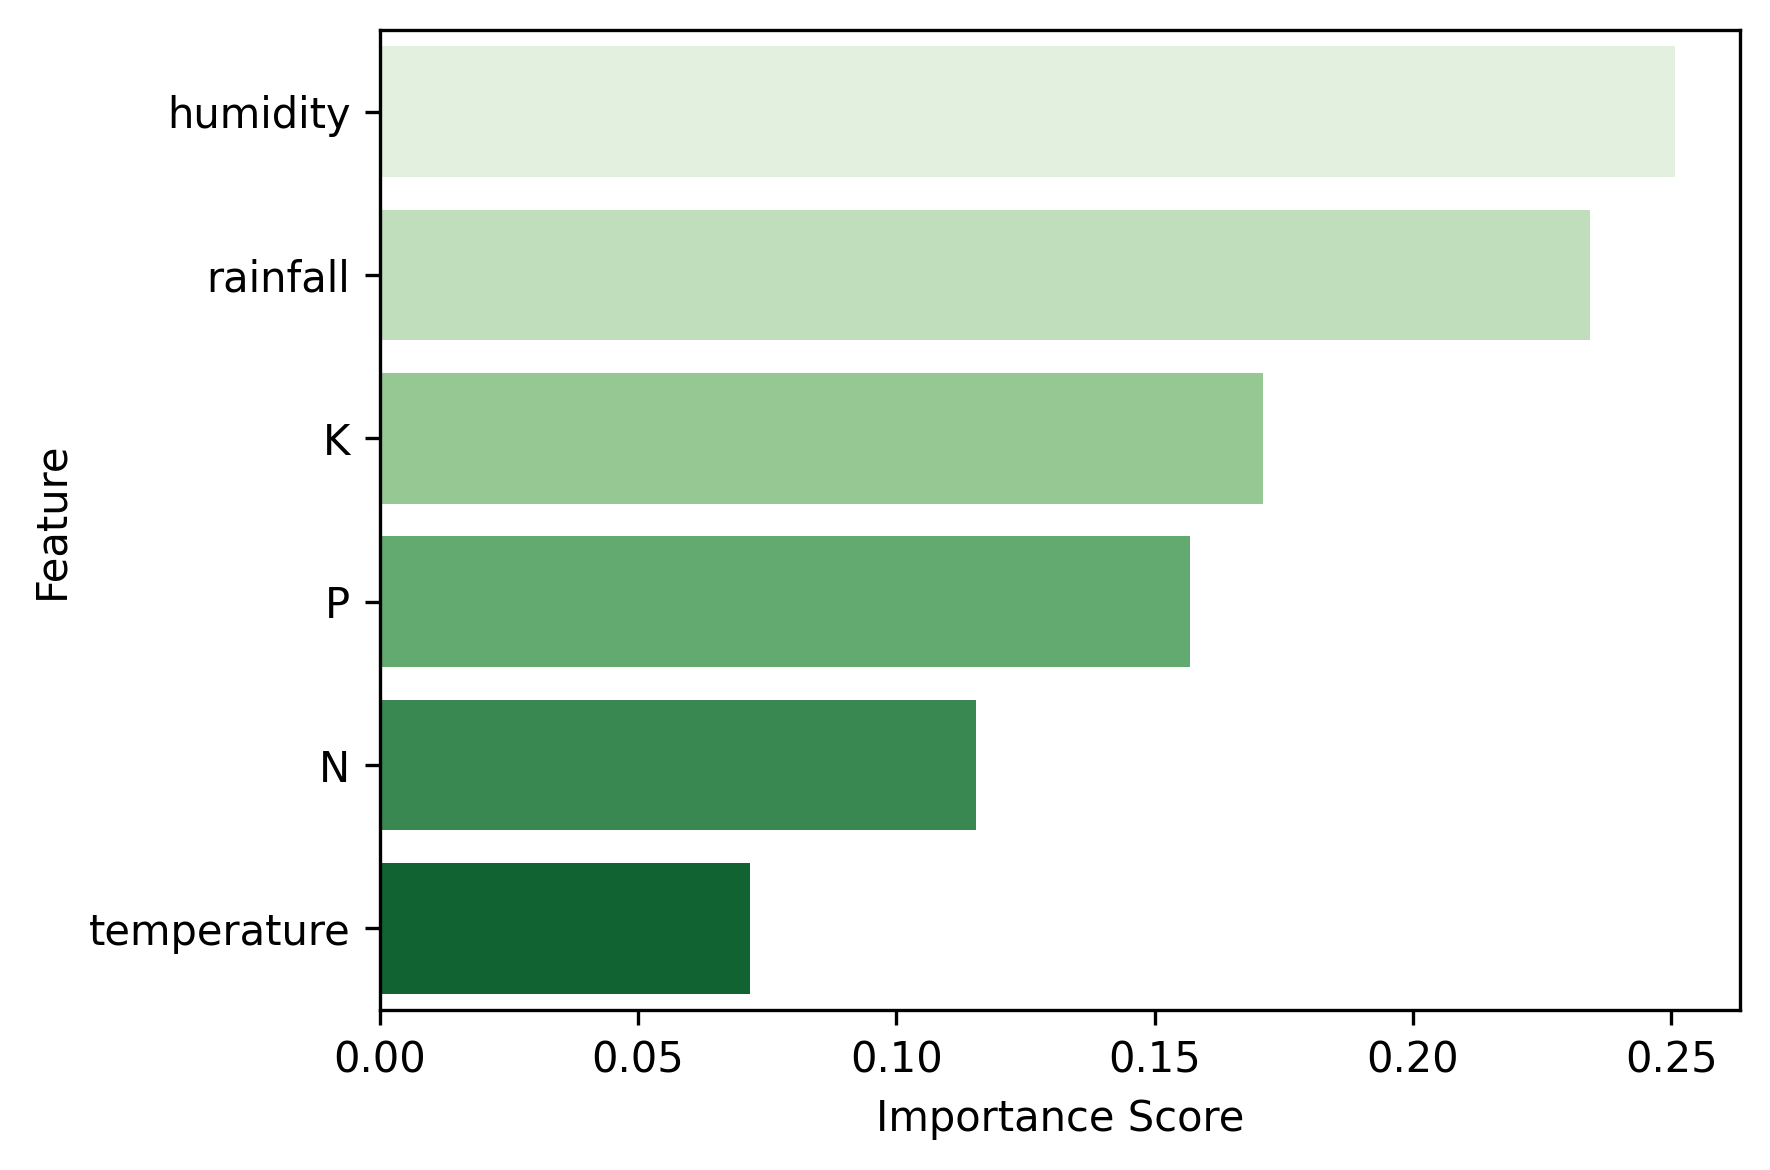

In [16]:
# ================================
# IEEE STYLE FEATURE IMPORTANCE
# ================================

# Get best Random Forest again
best_rf = best_models["Random Forest"]

# Extract feature importance
importances = best_rf.feature_importances_

# Create dataframe
fi_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(6,4), dpi=300)

sns.barplot(
    x="Importance",
    y="Feature",
    data=fi_df,
    palette=sns.color_palette("Greens", len(fi_df))
)

plt.xlabel("Importance Score", fontsize=10)
plt.ylabel("Feature", fontsize=10)

plt.tight_layout()

plt.savefig("feature_importance.pdf", format="pdf")
plt.savefig("feature_importance.png", dpi=600)

plt.show()

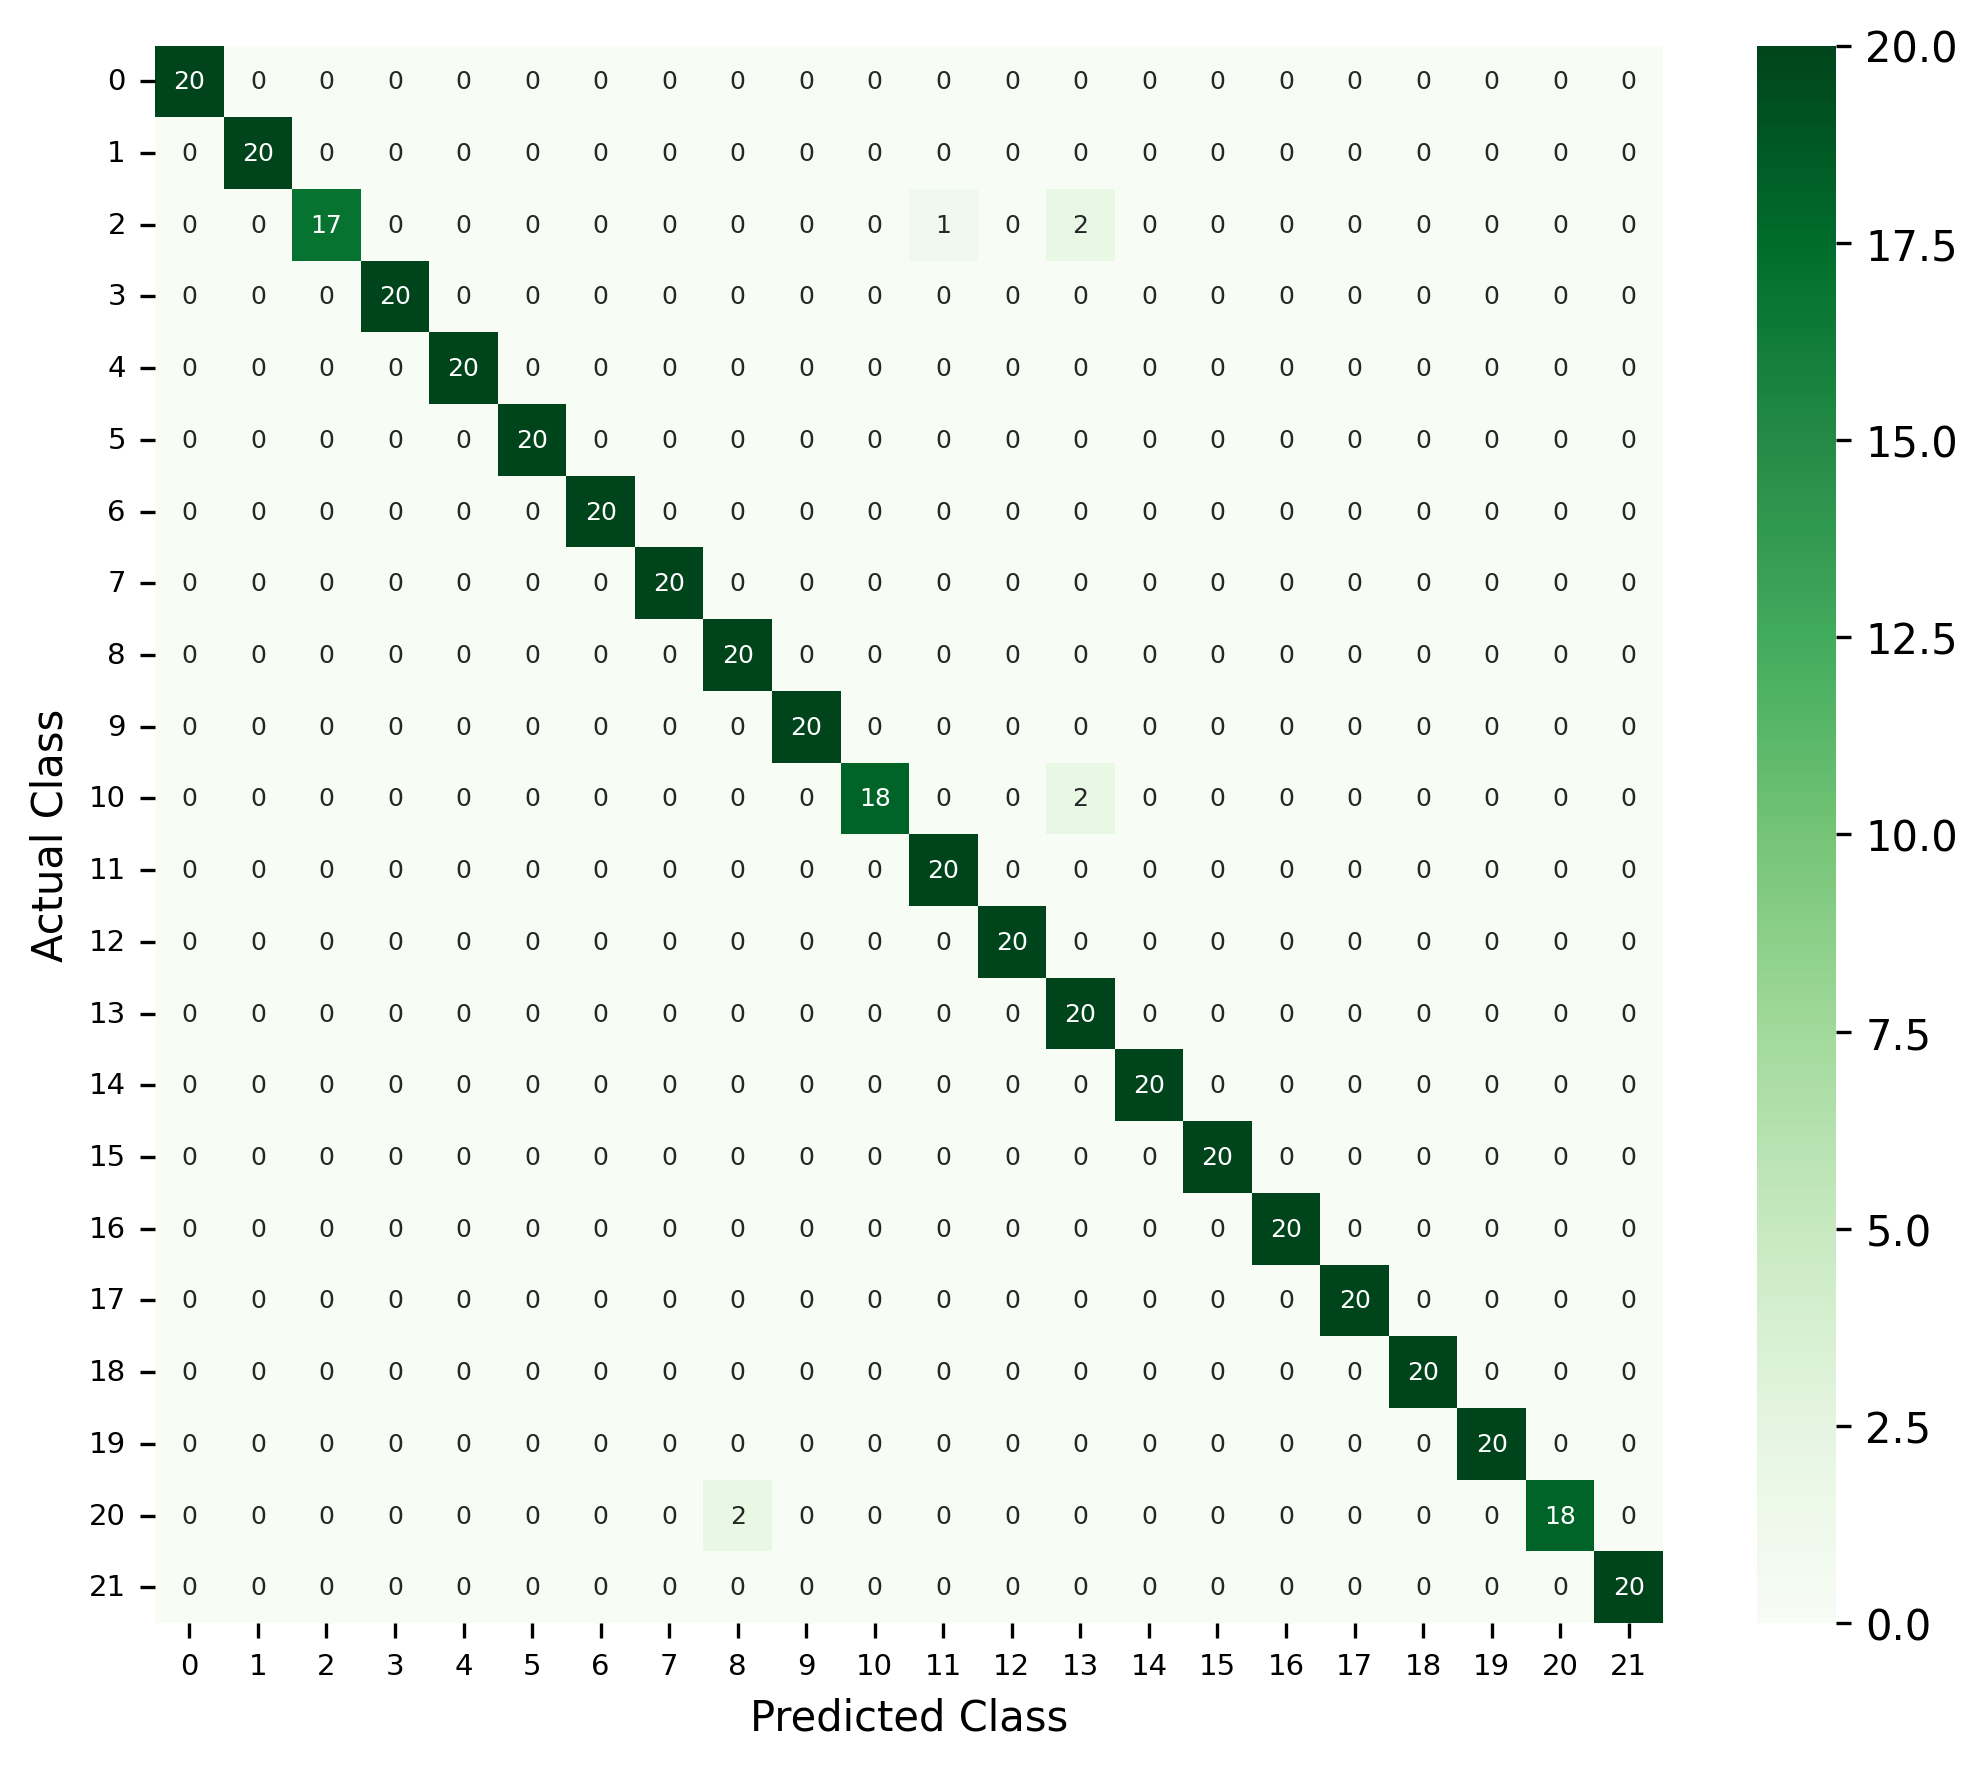


Classification Report – Random Forest (GridSearchCV)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.85      0.92        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.83      1.00      0.91        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00   

In [19]:
# ================================
# IEEE STYLE CONFUSION MATRIX (Numeric Labels)
# ================================

# Generate predictions
best_rf = best_models["Random Forest"]
rf_pred = best_rf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, rf_pred)

# Create numeric class labels
num_classes = len(np.unique(y_test))
numeric_labels = list(range(num_classes))

# Convert to DataFrame
cm_df = pd.DataFrame(
    cm,
    index=numeric_labels,
    columns=numeric_labels
)

cm_df.index.name = "Actual Class"
cm_df.columns.name = "Predicted Class"

# Save CSV
cm_df.to_csv("confusion_matrix_RF_numeric.csv")

# Plot
plt.figure(figsize=(7,6), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=numeric_labels,
    yticklabels=numeric_labels,
    annot_kws={"size":6},
    cbar=True
)

plt.xlabel("Predicted Class", fontsize=10)
plt.ylabel("Actual Class", fontsize=10)

plt.xticks(rotation=0, fontsize=7)
plt.yticks(rotation=0, fontsize=7)

plt.tight_layout()

plt.savefig("confusion_matrix_RF_numeric.pdf", format="pdf")
plt.savefig("confusion_matrix_RF_numeric.png", dpi=600)

plt.show()
print("\nClassification Report – Random Forest (GridSearchCV)\n")
print(classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_
))


In [18]:
# ======================================
# SAVE PROCESSED DATASETS
# ======================================

# Save cleaned dataset
data.to_csv("processed_crop_data.csv", index=False)

# Save scaled train/test features
pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).to_csv("X_train_scaled.csv", index=False)

pd.DataFrame(
    X_test_scaled,
    columns=X.columns
).to_csv("X_test_scaled.csv", index=False)

# Save encoded labels
pd.DataFrame(y_train, columns=["label"]).to_csv("y_train.csv", index=False)

pd.DataFrame(y_test, columns=["label"]).to_csv("y_test.csv", index=False)

print("✅ Processed datasets saved successfully")

✅ Processed datasets saved successfully
